In [14]:
import pandas as pd
import numpy as np
import re
from datetime import datetime
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn import metrics
from sklearn.metrics import classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import cross_val_score



#bundesland = "brandenburg"
#bundesland = "berlin"
bundesland = "baden-wuerttemberg"

only_passed_bill_traces = True

'''
# Berlin:
start_date = "2006-10-26"
end_date = "2021-11-04"
INPUT_FILE_NAME = './data-csv/case-logs/Berlin-with-topics-and-agreement-scores-all-time.csv'
'''

''' 
# Brandenburg:
start_date = "2004-10-13"
end_date = "2019-09-25"
INPUT_FILE_NAME = './data-csv/case-logs/Brandenburg-with-topics-and-agreement-scores-all-time-preprocessed.csv'
'''


# Baden-Württemberg:
start_date = "2006-06-01"
end_date = "2021-05-01"
INPUT_FILE_NAME = './data-csv/case-logs/Baden-Württemberg-with-topics-and-agreement-scores-all-time-preprocessed.csv'


INPUT_FILE_NAME_COMPARISON = './data-csv/case-logs/Baden-Württemberg-with-topics-and-agreement-scores-all-time-preprocessed.csv'
start_date_comparison = "2006-06-01"
end_date_comparison = "2021-05-01"




In [15]:
DATA_TYPES = {}

df = pd.read_csv(INPUT_FILE_NAME, dtype=DATA_TYPES)
print('Read', len(df), 'rows from', INPUT_FILE_NAME)
df = df.dropna(axis=1, how='all')  # drop all completely empty columns

df_comparison = pd.read_csv(INPUT_FILE_NAME_COMPARISON, dtype=DATA_TYPES)
print('Read', len(df_comparison), 'rows from', INPUT_FILE_NAME_COMPARISON)
df_comparison = df_comparison.dropna(axis=1, how='all')  # drop all completely empty columns
#df.info(verbose=True)

if only_passed_bill_traces:
    df = df[df['case:is_passed_bill'] == 1]
    print('Filtered to only passed bill traces, remaining rows:', len(df))
    df_comparison = df_comparison[df_comparison['case:is_passed_bill'] == 1]
    print('Filtered to only passed bill traces, remaining rows in comparison dataset:', len(df_comparison))

Read 1465 rows from ./data-csv/case-logs/Baden-Württemberg-with-topics-and-agreement-scores-all-time-preprocessed.csv
Read 1465 rows from ./data-csv/case-logs/Baden-Württemberg-with-topics-and-agreement-scores-all-time-preprocessed.csv
Filtered to only passed bill traces, remaining rows: 833
Filtered to only passed bill traces, remaining rows in comparison dataset: 833


In [16]:
# filter the data by date

print("df rows before filtering by date:", len(df))
print("df_comparison rows before filtering by date:", len(df_comparison))

# Calculate end_date by adding duration (in days) to start_time
df['end_time'] = pd.to_datetime(df['start_time']) + pd.to_timedelta(df['duration'], unit='D')
df = df[(df['start_time'] >= start_date) & (df['end_time'] <= end_date)]

df_comparison['end_time'] = pd.to_datetime(df_comparison['start_time']) + pd.to_timedelta(df_comparison['duration'], unit='D')
df_comparison = df_comparison[(df_comparison['start_time'] >= start_date_comparison) & (df_comparison['end_time'] <= end_date_comparison)]

df.drop(columns=['end_time'], inplace=True)
df_comparison.drop(columns=['end_time'], inplace=True)

print("df rows after filtering by date:", len(df))
print("df_comparison rows after filtering by date:", len(df_comparison))

df rows before filtering by date: 833
df_comparison rows before filtering by date: 833
df rows after filtering by date: 335
df_comparison rows after filtering by date: 335


In [17]:
# compute mean cycle time to compare against - cases taking longer than 10% above the mean cycle time are considered "long-running" cases

bawue_average_cycle_time = df_comparison["duration"].mean()
bawue_average_cycle_time_upper_bound = bawue_average_cycle_time + 0.1*bawue_average_cycle_time
bawue_average_cycle_time_lower_bound = bawue_average_cycle_time - 0.1*bawue_average_cycle_time

outcome_function = lambda row: row['duration'] > bawue_average_cycle_time_upper_bound

print("average_cycle_time:", bawue_average_cycle_time_lower_bound)

average_cycle_time: 81.88119402985075


In [18]:
# split into data and target
target = df.apply(outcome_function, axis=1)
data = df

In [19]:
# remove columns with object type
columns_type_object = data.select_dtypes(include=['object']).columns

print('Columns with object type:', columns_type_object)

data = data.drop(columns=columns_type_object)

# Replace all NaN values with 0
data = data.fillna(0)



Columns with object type: Index(['start_time', 'case:DokTypLFirstDoc', 'case:VSysL',
       'case:VorgangsDeskriptoren', 'case:author_first_activity'],
      dtype='object')


In [20]:
# Use attribute names or regular expressions to hide

##### general hiding of features that are never supposed to be used for prediction 
# (e.g., because they are meaningless or because they are too closely related to the target variable) ######
HIDE = [
    # hide what we want to explain
    'duration',
    r'.*cycle.*',
    r'.*Gesetz.*',
    r'.*Bekanntmachung.*',
    
    # hide meaningless columns
    'case_id',
    r'.*none.*',
    r'.*nan.*',
    
    # temporal columns
    'start_time_rel',
    'start_time', 
    'end_time',
    r'.*start.*', 
    ]



# hide strong control-flow features (delay and count)
HIDE.extend([
    r'.*delay.*',  
    #r'.*count.*',
    
    # does this belong here or in the political features? It is the feature saying if an Gesetz activity exists
    
    #"case:is_passed_bill",

    #r'.*:[0-9].*',
])


'''
# HIDE political features (uncomment the following lines to hide political features, comment them to include political features in the analysis)
HIDE.extend([
    r'.*score.*', # hides all the wahl-o-mat agreement score features
    "case:is_election_year",
    "case:is_passed_bill",
    "case:Wp",
    "case:half_year_index",
    "case:government_party_count",
    "case:opposition_party_count",
    "case:author_first_activity_count"
])
'''



for pattern in HIDE:
    for col in data.columns:
        if re.fullmatch(pattern, col):
            # print('Dropping {} on pattern "{}".'.format(col, pattern))
            data = data.drop(columns=[col])

In [21]:
X = data.to_numpy()
target = target.to_numpy()

x_train, x_test, y_train, y_test = train_test_split(X, target, test_size=0.33, random_state=42)

print('Train data:', len(x_train))
print('Test data:', len(x_test))

Train data: 224
Test data: 111


In [22]:
def createConfusionMatrix(y_test_arg, y_pred_arg, nameForSaving):
    
    print(classification_report(y_test_arg, y_pred_arg))
    tn, fp, fn, tp = metrics.confusion_matrix(y_test_arg, y_pred_arg).ravel()

    # Reorder the confusion matrix so positive-positive (tp) is in the upper left
    cm = np.array([[tp, fn],
                   [fp, tn]])

    # Define the class labels
    class_names = ["Positive", "Negative"] 

    # Create the plot with smaller figure size for papers
    fig, ax = plt.subplots(figsize=(5, 4))
    
    # Set fixed colormap limits to ensure consistent colors across different matrices
    # You can adjust these values based on your expected range of values
    vmin = 0
    vmax = 100  # Use either the max value or 100, whichever is greater
    
    # Apply the fixed color range to matshow
    cax = ax.matshow(cm, cmap='Blues', vmin=vmin, vmax=vmax)
    
    # Make the colorbar smaller and with larger font
    cbar = fig.colorbar(cax, shrink=0.8)
    cbar.ax.tick_params(labelsize=14)

    # Set axis ticks and labels with larger font
    ax.set_xticks(np.arange(len(class_names)))
    ax.set_yticks(np.arange(len(class_names)))
    ax.set_xticklabels(class_names, fontsize=14)
    ax.set_yticklabels(class_names, fontsize=14)

    # Set title and y-axis label with larger font
    plt.ylabel('True Labels', fontsize=16)
    
    # Add "Predicted Labels" on top instead of bottom
    ax.set_xlabel('Predicted Labels', fontsize=16)
    ax.xaxis.set_label_position('top') 

    # Annotate cells with counts using larger font
    for (i, j), val in np.ndenumerate(cm):
        ax.text(j, i, f"{val}", ha='center', va='center', color='black', fontsize=16, weight='bold')

    # Adjust layout and spacing
    plt.tight_layout()
    
    # Additional spacing adjustments to prevent label cutoff
    plt.subplots_adjust(left=0.2, bottom=0.2)
    
    # Save figure with high resolution
    #plt.savefig(nameForSaving, dpi=300, bbox_inches='tight')
    plt.show()
    

    
def baselinePredictor(y_train, x_test, y_test):
    countTrue = np.sum(y_train)
    percentageTrue = countTrue / len(y_train)
    # Generate random predictions for x_test based on the proportion of True
    np.random.seed(42)
    random_predictions = np.random.choice([True, False], size=len(x_test), p=[percentageTrue, 1 - percentageTrue])
    print("Random baseline (preserving y_train distribution) results:\n")
    createConfusionMatrix(y_test, random_predictions, "baselinePredictor" + bundesland + ".png")
    print("\n")
    


def majority_baseline(y_train, x_test, y_test):
    # Find the most frequent class in training data
    count_true = np.sum(y_train)
    count_false = len(y_train) - count_true
    
    majority_class = True if count_true >= count_false else False
    
    # Predict the majority class for all test samples
    y_pred = np.full(len(x_test), majority_class)
    
    print("Majority baseline results:\n")
    createConfusionMatrix(y_test, y_pred, "majority_baseline.png")
    print("\n")
    

Random baseline (preserving y_train distribution) results:

              precision    recall  f1-score   support

       False       0.78      0.69      0.73        87
        True       0.21      0.29      0.24        24

    accuracy                           0.60       111
   macro avg       0.49      0.49      0.49       111
weighted avg       0.66      0.60      0.63       111



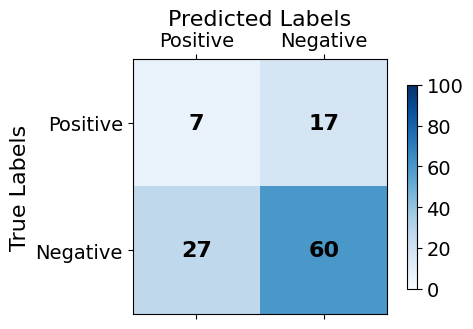



Majority baseline results:

              precision    recall  f1-score   support

       False       0.78      1.00      0.88        87
        True       0.00      0.00      0.00        24

    accuracy                           0.78       111
   macro avg       0.39      0.50      0.44       111
weighted avg       0.61      0.78      0.69       111



/Users/paul/miniconda3/envs/pm4py-env/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/paul/miniconda3/envs/pm4py-env/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/paul/miniconda3/envs/pm4py-env/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"

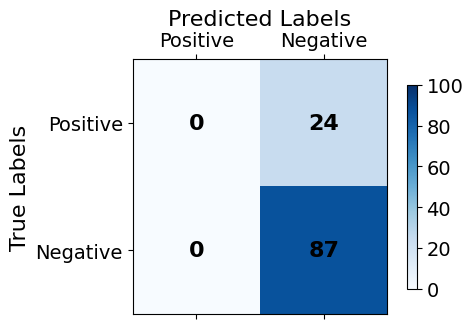

In [23]:
baselinePredictor(y_train, x_test, y_test)

majority_baseline(y_train, x_test, y_test)

pipe score: 0.8018018018018018
              precision    recall  f1-score   support

       False       0.83      0.94      0.88        87
        True       0.58      0.29      0.39        24

    accuracy                           0.80       111
   macro avg       0.71      0.62      0.64       111
weighted avg       0.78      0.80      0.78       111



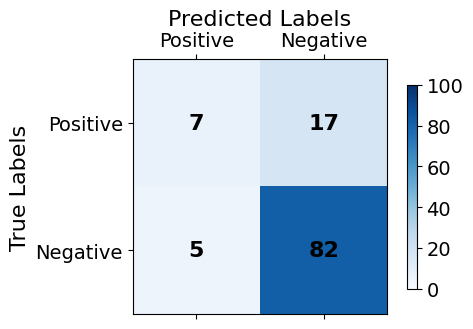


Features and their coefficient from the logistic regressor (normal pipe):

event_count: 2.737903766755396
Änderungsantrag.count: -1.060916826896549
Änderungsanträge (Sammeldrucksache).count: -0.8816506559211377
Änderungs- und Entschließungsanträge (Sammeldrucksache).count: -0.7721919676903096
Zweite und Dritte Beratung.count: -0.7036065910885866
Anträge, Änderungs- und Entschließungsanträge (Sammeldrucksache).count: -0.6834876631394029
Entschließungsantrag.count: -0.6691944400805963
Beschluss des Landtags in Dritter Beratung.count: -0.661274514282576
Zweite Beratung.count: -0.4544921024828602
case:author_first_activity_count: -0.36574322669311865
Erste Beratung.count: 0.3608091992788948
Mitteilung.count: 0.3188564951017347
Beschlussempfehlungen und Berichte (Sammeldrucksache).count: 0.29663198510236105
Aktuelle Debatte.count: -0.27960731977068853
Antrag.count: 0.2492927532551372
Regierungsinformation.count: -0.23962181344761566
Beschluss des Landtags in Zweiter Beratung.count: 0.20705

In [24]:
pipe = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, fit_intercept=True, random_state=42))
pipe.fit(x_train, y_train)
print("pipe score:", pipe.score(x_test, y_test))
y_pred = pipe.predict(x_test)
createConfusionMatrix(y_test, y_pred, "logisticRegression" + bundesland + ".png")

# Access the final estimator
regressor_normal = pipe.steps[-1][1]

# get names of features that were selected
print("\nFeatures and their coefficient from the logistic regressor (normal pipe):\n")

# Get the coefficients and their corresponding feature names
coefficients_normal = regressor_normal.coef_[0]
features_normal = data.columns

# Combine them into a list of tuples
feature_coefficients_normal = list(zip(features_normal, coefficients_normal))

# Sort the list by the absolute value of the coefficients in descending order
sorted_feature_coefficients_normal = sorted(feature_coefficients_normal, key=lambda x: abs(x[1]), reverse=True)

# Print the sorted features and their coefficients
for feature, coef in sorted_feature_coefficients_normal:
    print(f"{feature}: {coef}")

print("\nIntercept:", regressor_normal.intercept_)

#### Feature selection

In [25]:

# Define the range of C values to test
C_values = np.linspace(0.001, 0.1, 50)

# Initialize variables to store the best C and its corresponding score
best_C = None
best_score = -np.inf

# Loop over each C value
for C in C_values:
    print(f"Testing C={C}")
    
    # Step 1: Scale the data
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(X)
    
    # Step 2: Select features using LinearSVC with the current C value
    lsvc = LinearSVC(C=C, penalty="l1", dual=False, max_iter=1000).fit(scaled_data, target)
    model = SelectFromModel(lsvc, prefit=True)
    X_new = model.transform(X)
    
    # Step 3: Evaluate the selected features using Logistic Regression
    if X_new.shape[1] > 0:  # Ensure there are selected features
        clf = LogisticRegression(max_iter=1000)
        scores = cross_val_score(clf, X_new, target, cv=4, scoring='f1')  # 5-fold CV using f1 score as the evaluation metric
        mean_score = scores.mean()
        print(f"Mean cross-validation score with C={C}: {mean_score:.4f}")
        
        # Step 4: Update the best C if current score is better
        if mean_score > best_score:
            best_score = mean_score
            best_C = C
    else:
        print(f"No features selected with C={C}. Skipping evaluation.")

print(f"\nBest C value: {best_C} with a mean CV score of {best_score:.4f}")

# Retrain using the best C
scaler = StandardScaler()
scaled_data = scaler.fit_transform(X)
lsvc = LinearSVC(C=best_C, penalty="l1", dual=False, max_iter=1000).fit(scaled_data, target)
model = SelectFromModel(lsvc, prefit=True)
X_new = model.transform(X)

# Print selected features
print("data_new.shape:", X_new.shape)
print("\nSelected features:")
for columnName in data.columns[model.get_support()]:
    print(columnName)





Testing C=0.001
No features selected with C=0.001. Skipping evaluation.
Testing C=0.0030204081632653063
No features selected with C=0.0030204081632653063. Skipping evaluation.
Testing C=0.0050408163265306125
No features selected with C=0.0050408163265306125. Skipping evaluation.
Testing C=0.007061224489795919
No features selected with C=0.007061224489795919. Skipping evaluation.
Testing C=0.009081632653061226
Mean cross-validation score with C=0.009081632653061226: 0.1037
Testing C=0.011102040816326531
Mean cross-validation score with C=0.011102040816326531: 0.1037
Testing C=0.013122448979591837
Mean cross-validation score with C=0.013122448979591837: 0.1037
Testing C=0.015142857142857145
Mean cross-validation score with C=0.015142857142857145: 0.2030
Testing C=0.01716326530612245
Mean cross-validation score with C=0.01716326530612245: 0.2030
Testing C=0.019183673469387756
Mean cross-validation score with C=0.019183673469387756: 0.2030
Testing C=0.02120408163265306
Mean cross-validatio

/Users/paul/miniconda3/envs/pm4py-env/lib/python3.13/site-packages/sklearn/feature_selection/_base.py:122: UserWarning: No features were selected: either the data is too noisy or the selection test too strict.
  warnings.warn(
/Users/paul/miniconda3/envs/pm4py-env/lib/python3.13/site-packages/sklearn/feature_selection/_base.py:122: UserWarning: No features were selected: either the data is too noisy or the selection test too strict.
  warnings.warn(
/Users/paul/miniconda3/envs/pm4py-env/lib/python3.13/site-packages/sklearn/feature_selection/_base.py:122: UserWarning: No features were selected: either the data is too noisy or the selection test too strict.
  warnings.warn(
/Users/paul/miniconda3/envs/pm4py-env/lib/python3.13/site-packages/sklearn/feature_selection/_base.py:122: UserWarning: No features were selected: either the data is too noisy or the selection test too strict.
  warnings.warn(


Mean cross-validation score with C=0.04544897959183674: 0.1119
Testing C=0.047469387755102045
Mean cross-validation score with C=0.047469387755102045: 0.1917
Testing C=0.04948979591836735
Mean cross-validation score with C=0.04948979591836735: 0.2136
Testing C=0.051510204081632656
Mean cross-validation score with C=0.051510204081632656: 0.2136
Testing C=0.05353061224489796
Mean cross-validation score with C=0.05353061224489796: 0.2136
Testing C=0.05555102040816327
Mean cross-validation score with C=0.05555102040816327: 0.2136
Testing C=0.05757142857142858
Mean cross-validation score with C=0.05757142857142858: 0.2136
Testing C=0.059591836734693884
Mean cross-validation score with C=0.059591836734693884: 0.2445
Testing C=0.06161224489795919
Mean cross-validation score with C=0.06161224489795919: 0.2445
Testing C=0.0636326530612245
Mean cross-validation score with C=0.0636326530612245: 0.2722
Testing C=0.0656530612244898
Mean cross-validation score with C=0.0656530612244898: 0.2722
Testi

pipe_after_feature_selection score: 0.8288288288288288
              precision    recall  f1-score   support

       False       0.85      0.94      0.90        87
        True       0.67      0.42      0.51        24

    accuracy                           0.83       111
   macro avg       0.76      0.68      0.70       111
weighted avg       0.81      0.83      0.81       111



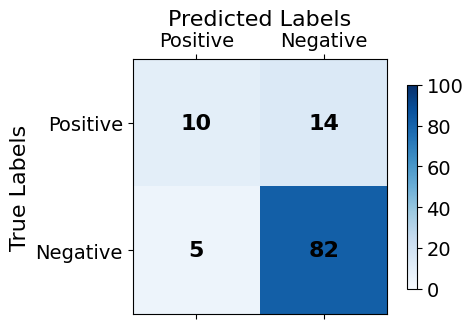


Selected features and their coefficient from the logistic regressor:

event_count: 2.237675601634755
Änderungsantrag.count: -0.9189914679950052
Zweite und Dritte Beratung.count: -0.7343155669573413
Änderungsanträge (Sammeldrucksache).count: -0.6811600580186962
Änderungs- und Entschließungsanträge (Sammeldrucksache).count: -0.6573648299335269
Anträge, Änderungs- und Entschließungsanträge (Sammeldrucksache).count: -0.5901274764585015
Entschließungsantrag.count: -0.5690156025631236
Beschluss des Landtags in Dritter Beratung.count: -0.5597083644029558
case:author_first_activity_count: -0.4117104648313144
Beschluss des Landtags in Zweiter Beratung.count: 0.3908442701337079
Zweite Beratung.count: -0.3375672813073313
Mitteilung.count: 0.32246923236665864
Beschlussempfehlungen und Berichte (Sammeldrucksache).count: 0.2785618944297632
Antrag.count: 0.26344456943797256
Regierungsinformation.count: -0.23154213316933775
Ergänzende Stellungnahme.count: 0.16019611372770912
Vorschlag.count: -0.11692

In [26]:

x_train_featureSelection, x_test_featureSelection, y_train_featureSelection, y_test_featureSelection = train_test_split(X_new, target, test_size=0.33, random_state=42)
pipe_after_feature_selection = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, fit_intercept=True, random_state=42))
pipe_after_feature_selection.fit(x_train_featureSelection, y_train_featureSelection)
pipe_after_feature_selection.score(x_test_featureSelection, y_test_featureSelection)
print("pipe_after_feature_selection score:", pipe_after_feature_selection.score(x_test_featureSelection, y_test_featureSelection))
y_pred_featureSelection = pipe_after_feature_selection.predict(x_test_featureSelection)
createConfusionMatrix(y_test_featureSelection, y_pred_featureSelection, "logisticRegression_featureSelection" + bundesland + ".png")

# Access the final estimator
regressor = pipe_after_feature_selection.steps[-1][1]

# get names of features that were selected
print("\nSelected features and their coefficient from the logistic regressor:\n")

# Get the coefficients and their corresponding feature names
coefficients = regressor.coef_[0]
features = data.columns[model.get_support()]

# Combine them into a list of tuples
feature_coefficients = list(zip(features, coefficients))

# Sort the list by the absolute value of the coefficients in descending order
sorted_feature_coefficients = sorted(feature_coefficients, key=lambda x: abs(x[1]), reverse=True)

# Print the sorted features and their coefficients
for feature, coef in sorted_feature_coefficients:
    print(f"{feature}: {coef}")

print("\nIntercept:", regressor.intercept_)

